In [ ]:
#łączymy dane
import pandas as pd

hormones = pd.read_csv("hormones_and_selfreport.csv")
sleep = pd.read_csv("sleep.csv")
subjects = pd.read_csv("subject-info.csv")

df = hormones.merge(subjects, on="id")

In [ ]:
print(hormones.columns)
print(subjects.columns)

Index(['id', 'study_interval', 'is_weekend', 'day_in_study', 'phase', 'lh',
       'estrogen', 'pdg', 'flow_volume', 'flow_color', 'appetite',
       'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue',
       'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion',
       'bloating'],
      dtype='object')
Index(['id', 'birth_year', 'gender', 'ethnicity', 'education',
       'sexually_active', 'self_report_menstrual_health_literacy',
       'age_of_first_menarche'],
      dtype='object')


In [ ]:
#tworzymy true_label
df["true_label"] = (df["lh"] > 25).astype(int)

In [ ]:
#tworzymy fake predicted_probability
import numpy as np

df["predicted_probability"] = np.random.uniform(
    0.2,
    0.9,
    size=len(df)
)

In [ ]:
#tworzymy predicted_label
df["predicted_label"] = (
    df["predicted_probability"] > 0.5
).astype(int)

In [ ]:
#tworzymy prediction_set (conformal simulation)
def make_prediction_set(p):

    if p > 0.8:
        return {1}

    elif p < 0.2:
        return {0}

    else:
        return {0,1}

df["prediction_set"] = df["predicted_probability"].apply(
    make_prediction_set
)

In [ ]:
#tworzę compute_metrics(), to jest to do liczenia tych precision, recall, accuracy
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import brier_score_loss


def compute_metrics(df):

    y_true = df["true_label"]
    y_pred = df["predicted_label"]
    y_prob = df["predicted_probability"]

    metrics = {}

    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred)
    metrics["recall"] = recall_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred)
    metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    metrics["brier"] = brier_score_loss(y_true, y_prob)

    return metrics

In [ ]:
compute_metrics(df)

{'accuracy': 0.42304294044884255,
 'precision': 0.023824068417837508,
 'recall': 0.5306122448979592,
 'f1': 0.0456007015492546,
 'roc_auc': np.float64(0.4928443075343345),
 'brier': np.float64(0.3435347521239961)}

In [ ]:
#tworzę bootstrap_ci(), do liczenia przedziału ufności
import numpy as np
from sklearn.metrics import accuracy_score


def bootstrap_ci(df, n_bootstrap=1000):

    accuracies = []

    participants = df["id"].unique()

    for _ in range(n_bootstrap):

        sampled_ids = np.random.choice(
            participants,
            size=len(participants),
            replace=True
        )

        sample = df[
            df["id"].isin(sampled_ids)
        ]

        acc = accuracy_score(
            sample["true_label"],
            sample["predicted_label"]
        )

        accuracies.append(acc)

    lower = np.percentile(accuracies, 2.5)
    upper = np.percentile(accuracies, 97.5)

    return lower, upper

In [ ]:
bootstrap_ci(df)

(np.float64(0.41354808452844327), np.float64(0.4337472589817516))

In [ ]:
#tworzę compute_coverage() - gwarancja statystyczna
def compute_coverage(df):

    correct = df.apply(
        lambda row: row["true_label"] in row["prediction_set"],
        axis=1
    )

    coverage = correct.mean()

    return coverage

In [ ]:
compute_coverage(df)

np.float64(0.8595158155151087)

In [ ]:
#tworzę plot_reliability_diagram() - jeśli mam 10% ryzyka choroby, to jestem pewna że to właśnie 1 na 10 przypadków
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve


def plot_reliability_diagram(df):

    y_true = df["true_label"]
    y_prob = df["predicted_probability"]

    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=10
    )

    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0,1],[0,1], linestyle="--")

    plt.xlabel("Predicted probability")
    plt.ylabel("True probability")

    plt.title("Reliability diagram")

    plt.show()

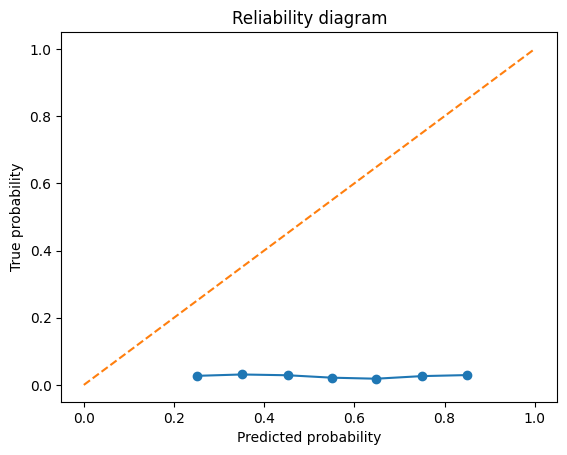

In [ ]:
#moje przyszłe Figure 3
plot_reliability_diagram(df)

In [ ]:
#tworzę plot_coverage_error_curve() - nie biorę próbki ale za to mam mniejszą liczbę błędów
def plot_coverage_error_curve(df):

    thresholds = np.linspace(0.5, 1, 20)

    coverage_values = []
    error_values = []

    for t in thresholds:

        subset = df[
            df["predicted_probability"] >= t
        ]

        if len(subset) == 0:
            continue

        coverage = len(subset) / len(df)

        error = 1 - accuracy_score(
            subset["true_label"],
            subset["predicted_label"]
        )

        coverage_values.append(coverage)
        error_values.append(error)

    plt.plot(coverage_values, error_values)

    plt.xlabel("Coverage")
    plt.ylabel("Error")

    plt.title("Coverage-error tradeoff")

    plt.show()

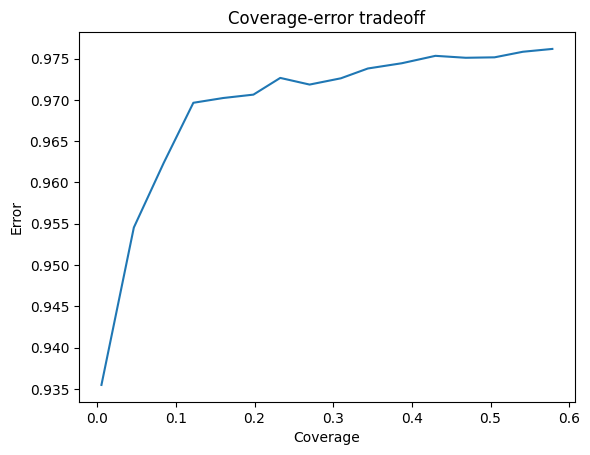

In [ ]:
#moje przyszłe Figure 2
plot_coverage_error_curve(df)

In [ ]:
import pandas as pd

df = pd.read_csv("wrist_temperature.csv")
df.head()

,id,study_interval,is_weekend,day_in_study,timestamp,temperature_diff_from_baseline
0,1,2022,False,3,00:00:00,0.023913
1,1,2022,False,3,00:01:00,-0.021087
2,1,2022,False,3,00:02:00,-0.101087
3,1,2022,False,3,00:03:00,-0.196087
4,1,2022,False,3,00:04:00,-0.236087
